# 20_pairwise_interactions.ipynb

In [ ]:
# Import appropriate configuration information
from pathlib import Path
path = Path.cwd().parent.parent
HYPERPARAM_DEST = path / "notebooks" / "modeling"
DATA = path / "data" / "raw" / "imagingFeatures.csv"
TARGET = 'ER'

## Import the data

In [ ]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import json

# Fetch json object that will contain the optimal hyperparameters
with open(HYPERPARAM_DEST / "ER" / "ALL_IMG.json", "r") as f:
    results = json.load(f)

# Find the XGBoost entry
xgb_entry = next(m for m in results if m["model"] == "XGBoost")
xgb_best_params = xgb_entry["best_params"]

# Retrieve the data the model was trained on
clinical_data_path = path / "data" / "raw" / "clinicalData_clean.csv"
features = pd.read_csv(DATA)
features.rename(columns={'Patient.ID': 'Patient ID'}, inplace=True, errors='ignore')
clin = pd.read_csv(clinical_data_path)
data = features.merge(clin[['Patient ID', TARGET]], on='Patient ID', how='inner')
data = data.drop('Unnamed: 0', axis=1, errors='ignore').dropna() # Won't run if there are NA values
y = data[TARGET]
le = LabelEncoder()
y = le.fit_transform(y.astype(str))
X = data.drop([TARGET, 'Patient ID'], axis=1, errors='ignore') # same features used in training

# XGB model already fit on your favorite feature set
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', **xgb_best_params)
xgb_model.fit(X, y)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:45:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                           SER_Washout_tumor_vol_cu_mm                                               0.008247
SER_Washout_tumor_vol_cu_mm                                             1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                             0.008247
                                                                        Grouping_based_variance_of_peak_enhancement_slope_3D_tissue_T1_Group_1    0.005165
Grouping_based_variance_of_peak_enhancement_slope_3D_tissue_T1_Group_1  SER_Washout_tumor_vol_cu_mm                                               0.005165
1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                           Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_1                0.005103
Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_1              1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                             0.005103
Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1   

## SHAP Explainer
For each sample, allocate the model's prediction $\delta \hat{P} = f(x) - E[f(x)]$ across every ordered pair of features $(i, j)$ so that $\delta \hat{P} = \sum_i \phi_i (main) + \frac{1}{2}\sum_{i \neq j} \phi_{ij} (interaction)$.

* $\phi_i$: main-effect Shapley value
* $\phi_{ij}$: pairwise Shapley interaction value
* The algorithm treates "feature i present/absent" and "feature j present/absent" as a four-player coalition game and measures how much extra lift you get when both are present beyond what you'd expect from each alone

In [14]:
explainer = shap.TreeExplainer(xgb_model) # returns (n_samples, n_features, n_features)

interaction_vals = explainer.shap_interaction_values(X)

## Collapse
Turn the $n \times n \times n$ tensor into an $n \times n$ matrix of mean absolute interaction strengths.

In [15]:
# Mean |SHAP interaction| across samples
import numpy as np
mean_int = np.abs(interaction_vals).mean(axis=0)
np.fill_diagonal(mean_int, 0)              # drop main-effect diagonal
top_pairs = (
    pd.DataFrame(mean_int, index=X.columns, columns=X.columns)
      .stack()
      .sort_values(ascending=False)
      .head(50)                            # top 50 is usually plenty
)
top_pairs.to_csv("top_interactions_xgb.csv")
print(top_pairs.head(10))

1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                           SER_Washout_tumor_vol_cu_mm                                               0.008247
SER_Washout_tumor_vol_cu_mm                                             1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                             0.008247
                                                                        Grouping_based_variance_of_peak_enhancement_slope_3D_tissue_T1_Group_1    0.005165
Grouping_based_variance_of_peak_enhancement_slope_3D_tissue_T1_Group_1  SER_Washout_tumor_vol_cu_mm                                               0.005165
1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                           Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_1                0.005103
Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_1              1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor                             0.005103
Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1   

## Interactive table of the top pairs

In [16]:
top_df = (top_pairs
          .reset_index()
          .rename(columns={'level_0': 'Feature 1',
                           'level_1': 'Feature 2',
                           0:          '|mean SHAP interaction|'}))

# Show the first 25 rows sorted descending
display(top_df.head(25).style
        .format({'|mean SHAP interaction|': '{:,.4f}'})
        .background_gradient(cmap='Reds'))

,Feature 1,Feature 2,|mean SHAP interaction|
0,1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor,SER_Washout_tumor_vol_cu_mm,0.0082
1,SER_Washout_tumor_vol_cu_mm,1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor,0.0082
2,SER_Washout_tumor_vol_cu_mm,Grouping_based_variance_of_peak_enhancement_slope_3D_tissue_T1_Group_1,0.0052
3,Grouping_based_variance_of_peak_enhancement_slope_3D_tissue_T1_Group_1,SER_Washout_tumor_vol_cu_mm,0.0052
4,1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor,Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_1,0.0051
5,Grouping_based_proportion_of_tumor_voxels_3D_tumor_Group_1,1st_DFT_CoeffMap_Momment_Invariant_7_3D_tumor,0.0051
6,Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1,SER_Washout_tumor_vol_cu_mm,0.0049
7,SER_Washout_tumor_vol_cu_mm,Grouping_based_mean_of_peak_enhancement_slope_2D_tumorSlice_Group_1,0.0049
8,Mean_norm_DHOG_max_timepoint_binsize_4_with_filling_Tumor,SER_Washout_tumor_vol_cu_mm,0.0048
9,SER_Washout_tumor_vol_cu_mm,Mean_norm_DHOG_max_timepoint_binsize_4_with_filling_Tumor,0.0048


## Horizontal bar chart of the strongest interactions

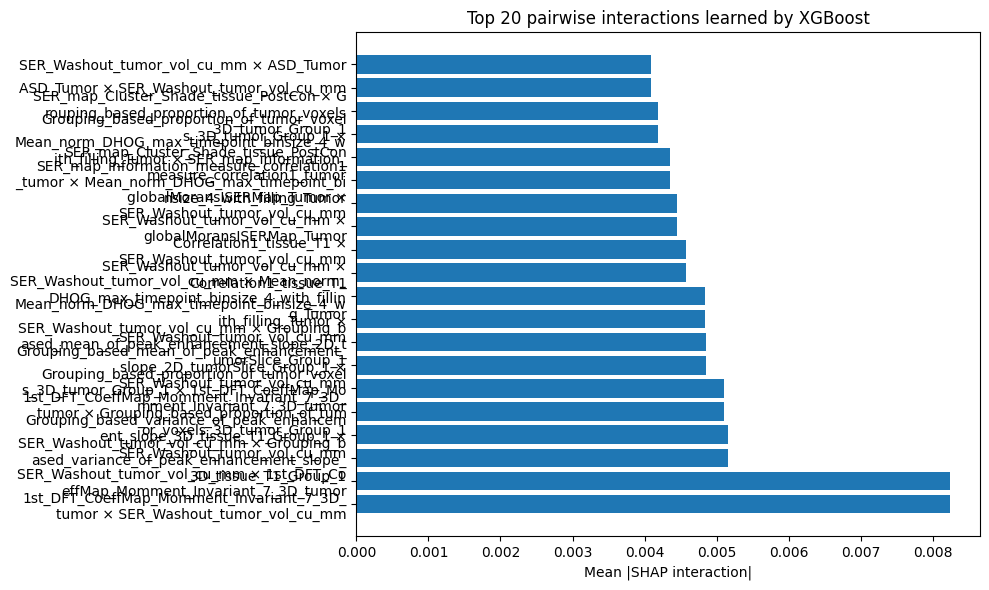

In [17]:
import matplotlib.pyplot as plt
import textwrap

N = 20                     # how many bars to show
pairs  = [f"{a} × {b}" for a, b in top_pairs.index[:N]]
values = top_pairs.values[:N]

plt.figure(figsize=(10, 6))
plt.barh(range(N)[::-1], values[::-1])    # biggest at the top
plt.yticks(range(N)[::-1],
           [textwrap.fill(p, 40) for p in pairs[::-1]], ha='right')
plt.xlabel('Mean |SHAP interaction|')
plt.title('Top 20 pairwise interactions learned by XGBoost')
plt.tight_layout()
plt.show()